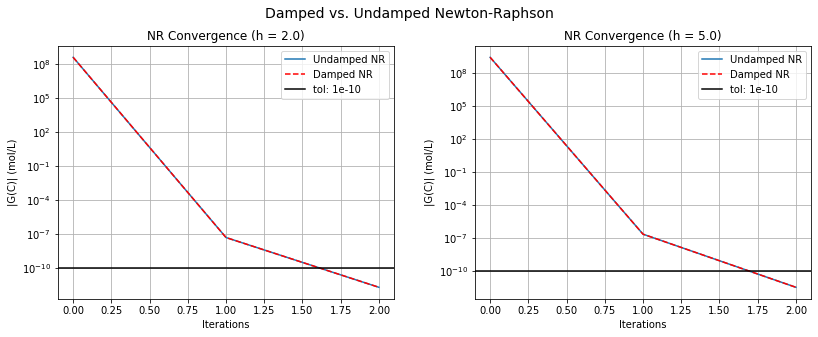

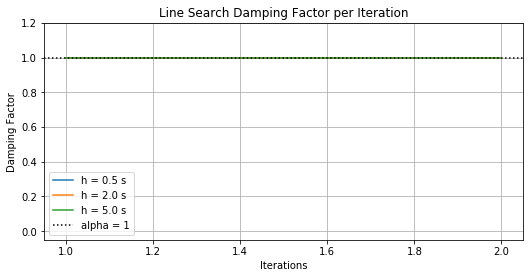

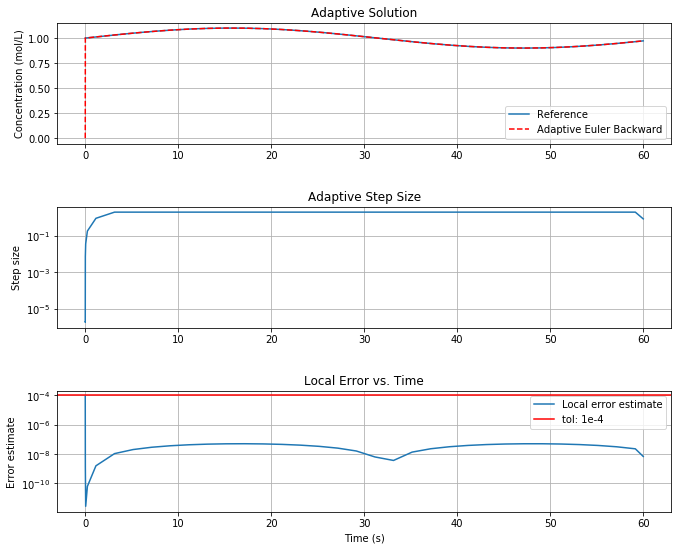

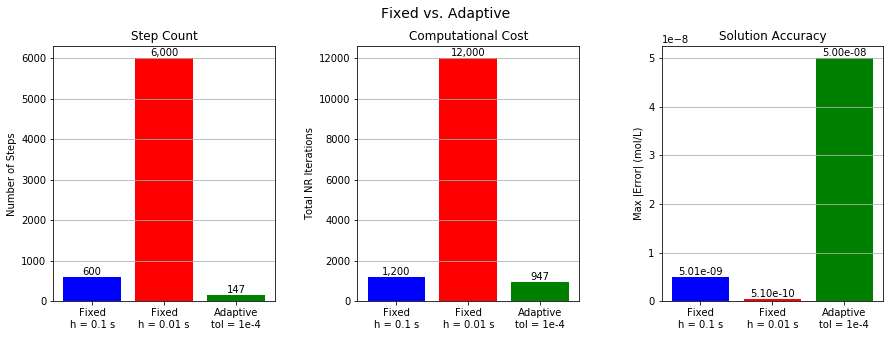

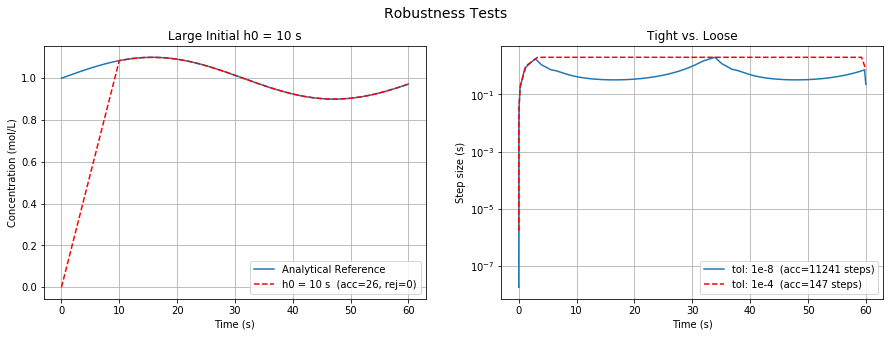

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

k  = 1e4
C0 = 0.0
T  = 60.0

def C_eq(t):
    return 1.0 + 0.1 * np.sin(0.1 * t)

def dCeq_dt(t):
    return 0.01 * np.cos(0.1 * t)

def f(t, C):
    return -k * (C - C_eq(t))

def analytical(t):
    return C_eq(t) - dCeq_dt(t) / k

def G(C_new, C_n, t_next, h):
    return C_new - C_n - h * f(t_next, C_new)

def dGdC(h):
    return 1.0 + h * k

# damped nr
def damped_newton_raphson(C_n, t_next, h, tol=1e-10, max_iter=20, alpha_min=1e-4):
    # damped nr with line search
    C = C_n + h * f(t_next - h, C_n)
    alpha_history = []
    total_backtracks = 0
    for i in range(max_iter):
        g = G(C, C_n, t_next, h)
        if abs(g) < tol:
            return C, i + 1, True, alpha_history, total_backtracks
        delta = -g / dGdC(h)
        alpha = 1.0
        g_abs = abs(g)
        backtracks = 0
        for _ in range(20):
            if abs(G(C + alpha * delta, C_n, t_next, h)) < g_abs:
                break
            alpha /= 2.0
            backtracks += 1
            if alpha < alpha_min:
                alpha_history.append(alpha)
                total_backtracks += backtracks
                return C, i + 1, False, alpha_history, total_backtracks
        alpha_history.append(alpha)
        total_backtracks += backtracks
        C = C + alpha * delta
    return C, max_iter, False, alpha_history, total_backtracks

def track_basic_residuals(C_n, t_next, h, max_iter=15):
    C = C_n + h * f(t_next - h, C_n)
    res = [abs(G(C, C_n, t_next, h))]
    for _ in range(max_iter):
        g = G(C, C_n, t_next, h)
        if abs(g) < 1e-10:
            break
        C = C - g / dGdC(h)
        res.append(abs(G(C, C_n, t_next, h)))
    return res

def track_damped_residuals(C_n, t_next, h, max_iter=15):
    C = C_n + h * f(t_next - h, C_n)
    res = [abs(G(C, C_n, t_next, h))]
    alphas = []
    for _ in range(max_iter):
        g = G(C, C_n, t_next, h)
        if abs(g) < 1e-10:
            break
        delta = -g / dGdC(h)
        alpha = 1.0
        g_abs = abs(g)
        for __ in range(20):
            if abs(G(C + alpha * delta, C_n, t_next, h)) < g_abs:
                break
            alpha /= 2.0
            if alpha < 1e-4:
                break
        alphas.append(alpha)
        C += alpha * delta
        res.append(abs(G(C, C_n, t_next, h)))
    return res, alphas

# one step
def one_step(C_n, t_next, h, tol=1e-10):
    C_new, iters, _, _, _ = damped_newton_raphson(C_n, t_next, h, tol=tol)
    return C_new, iters

# two half steps
def step_doubling(C_n, t_n, h, tol=1e-10):
    
    y_full, it1 = one_step(C_n,   t_n + h,   h,   tol)
    y_mid,  it2 = one_step(C_n,   t_n + h/2, h/2, tol)
    y_half, it3 = one_step(y_mid, t_n + h,   h/2, tol)
    return y_full, y_half, abs(y_half - y_full), it1 + it2 + it3

# step size adjustment
def adjust_step(h, err, tol, safety=0.9, h_min=1e-6, h_max=2.0):

    if err < 1e-14:
        return min(2.0 * h, h_max)
    h_new = safety * h * np.sqrt(tol / err)
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    return max(h_min, min(h_max, h_new))

# euler's backward with damped NR
def adaptive_implicit_euler(C0_=None, t0=0.0, t_final=T,
                             h0=0.1, tol=1e-4,
                             h_min=1e-6, h_max=2.0, safety=0.9,
                             nr_tol=1e-10):
    
    # uses more accurate half step stuff
    if C0_ is None:
        C0_ = C0
    t_list = [t0]; C_list = [C0_]; h_hist = []; e_hist = []
    stats = {'accepted': 0, 'rejected': 0, 'nr_iters': 0, 'func_evals': 0}
    h = h0; t_cur = t0; C_cur = C0_
    while t_cur < t_final - 1e-12:
        h = min(h, t_final - t_cur)
        y_full, y_half, err, nr_it = step_doubling(C_cur, t_cur, h, tol=nr_tol)
        stats['nr_iters']   += nr_it
        stats['func_evals'] += nr_it * 2
        h_new = adjust_step(h, err, tol, safety, h_min, h_max)
        if err < tol:
            t_cur += h; C_cur = y_half
            t_list.append(t_cur); C_list.append(C_cur)
            h_hist.append(h); e_hist.append(err)
            stats['accepted'] += 1
        else:
            stats['rejected'] += 1
        h = h_new
    return (np.array(t_list), np.array(C_list),
            np.array(h_hist), np.array(e_hist), stats)

# adaptive step size euler's backward with nr
def adaptive_with_attempts(C0_=None, t0=0.0, t_final=T,
                            h0=0.5, tol=1e-4,
                            h_min=1e-6, h_max=2.0, safety=0.9):
    
    if C0_ is None:
        C0_ = C0
    t_list = [t0]; C_list = [C0_]
    att_t = []; att_h = []; att_ok = []
    h = h0; t_cur = t0; C_cur = C0_
    while t_cur < t_final - 1e-12:
        h = min(h, t_final - t_cur)
        y_full, y_half, err, _ = step_doubling(C_cur, t_cur, h)
        h_new = adjust_step(h, err, tol, safety, h_min, h_max)
        accepted = err < tol
        att_t.append(t_cur); att_h.append(h); att_ok.append(accepted)
        if accepted:
            t_cur += h; C_cur = y_half
            t_list.append(t_cur); C_list.append(C_cur)
        h = h_new
    return (np.array(t_list), np.array(C_list),
            np.array(att_t), np.array(att_h), np.array(att_ok))

# fixed step size euler's backward with nr
def fixed_euler_backward(h_step, t0=0.0, t_final=T, C0_=None):
    if C0_ is None:
        C0_ = C0
    t = np.arange(t0, t_final + h_step * 0.5, h_step)
    C = np.zeros(len(t)); C[0] = C0_
    total_iters = 0
    for n in range(len(t) - 1):
        C[n+1], it, *_ = damped_newton_raphson(C[n], t[n+1], h_step)
        total_iters += it
    return t, C, total_iters

# max error
def max_err(t_arr, C_arr):
    mask = t_arr > 1.0
    return np.max(np.abs(C_arr[mask] - analytical(t_arr[mask])))

t_ref = np.linspace(0, T, 5000)
C_ref = analytical(t_ref)

t_a, C_a, h_h, e_h, stats_a = adaptive_implicit_euler(h0=0.5, tol=1e-4)

t_f01,  C_f01,  it_f01  = fixed_euler_backward(0.1)
t_f001, C_f001, it_f001 = fixed_euler_backward(0.01)

t_r1, C_r1, _,    _, st1 = adaptive_implicit_euler(h0=10.0, tol=1e-4)

t_r2, C_r2, h_r2, _, st2 = adaptive_implicit_euler(h0=0.1, tol=1e-8, h_min=1e-10)
t_r3, C_r3, h_r3, _, st3 = adaptive_implicit_euler(h0=0.1, tol=1e-4)

t_v, C_v, att_t, att_h, att_ok = adaptive_with_attempts(h0=0.5, tol=1e-4)


# FIG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle("Damped vs. Undamped Newton-Raphson", fontsize=14)

for ax, h_test, title in zip(axes1, [2.0, 5.0], ["h = 2.0", "h = 5.0"]):
    rb = track_basic_residuals(0.0, h_test, h_test)
    rd, _ = track_damped_residuals(0.0, h_test, h_test)
    ax.semilogy(range(len(rb)), rb, label='Undamped NR')
    ax.semilogy(range(len(rd)), rd, ls='--', color='red', label='Damped NR')
    ax.axhline(1e-10, color='black', label='tol: 1e-10')
    ax.set_xlabel('Iterations')
    ax.set_ylabel('|G(C)| (mol/L)')
    ax.set_title(f'NR Convergence ({title})')
    ax.legend()
    ax.grid()

plt.tight_layout(pad=3)
plt.savefig('fig3-1_damping.png')
plt.show()

# FIG 2
fig2, ax2 = plt.subplots(figsize=(8, 4.5))
for h_test, lbl in zip([0.5, 2.0, 5.0], ['h = 0.5 s', 'h = 2.0 s', 'h = 5.0 s']):
    _, alphas = track_damped_residuals(0.0, h_test, h_test)
    if alphas:
        ax2.plot(range(1, len(alphas) + 1), alphas, label=lbl)

ax2.axhline(1.0, ls=':', color='black', label='alpha = 1')
ax2.set_xlabel('Iterations')
ax2.set_ylabel('Damping Factor')
ax2.set_title('Line Search Damping Factor per Iteration')
ax2.set_ylim(-0.05, 1.2)
ax2.legend()
ax2.grid()
plt.tight_layout(pad=3)
plt.savefig('fig3-2_alpha.png')
plt.show()


# FIG 3
fig3 = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(3, 1, hspace=0.52)

ax3a = fig3.add_subplot(gs[0])
ax3a.plot(t_ref, C_ref, label='Reference')
ax3a.plot(t_a, C_a, ls='--', color='red', label='Adaptive Euler Backward')
ax3a.set_ylabel('Concentration (mol/L)')
ax3a.set_title('Adaptive Solution')
ax3a.legend()
ax3a.grid()

ax3b = fig3.add_subplot(gs[1])
ax3b.semilogy(t_a[1:], h_h)
ax3b.set_ylabel('Step size')
ax3b.set_title('Adaptive Step Size')
ax3b.grid()

ax3c = fig3.add_subplot(gs[2])
ax3c.semilogy(t_a[1:], e_h + 1e-17, label='Local error estimate')
ax3c.axhline(1e-4, color='red', label='tol: 1e-4')
ax3c.set_xlabel('Time (s)')
ax3c.set_ylabel('Error estimate')
ax3c.set_title('Local Error vs. Time')
ax3c.legend()
ax3c.grid()

plt.savefig('fig3-3_adaptive.png')
plt.show()

# FIG 4
perf = {
    'Fixed\nh = 0.1 s':     (len(t_f01)  - 1, it_f01,           max_err(t_f01,  C_f01)),
    'Fixed\nh = 0.01 s':    (len(t_f001) - 1, it_f001,          max_err(t_f001, C_f001)),
    'Adaptive\ntol = 1e-4': (stats_a['accepted'], stats_a['nr_iters'], max_err(t_a, C_a)),
}
methods  = list(perf.keys())
steps_v  = [perf[m][0] for m in methods]
iters_v  = [perf[m][1] for m in methods]
errors_v = [perf[m][2] for m in methods]
cols     = ['blue', 'red', 'green']

fig4, axes4 = plt.subplots(1, 3, figsize=(13, 5))
fig4.suptitle("Fixed vs. Adaptive", fontsize=14)

for ax, vals, ylabel, title in zip(
        axes4,
        [steps_v, iters_v, errors_v],
        ['Number of Steps', 'Total NR Iterations', 'Max |Error| (mol/L)'],
        ['Step Count', 'Computational Cost', 'Solution Accuracy']):
    bars = ax.bar(methods, vals, color=cols)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis='x')
    ax.grid(axis='y')
    for bar, v in zip(bars, vals):
        if ylabel == 'Max |Error| (mol/L)':
            label = f'{v:.2e}'
        else: 
            label = f'{int(v):,}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                label, ha='center', va='bottom')

plt.tight_layout(pad=3)
plt.savefig('fig3-4_comparison.png')
plt.show()


# FIG 5
fig5, axes5 = plt.subplots(1, 2, figsize=(13, 5))
fig5.suptitle("Robustness Tests", fontsize=14)

axes5[0].plot(t_ref, C_ref, label='Analytical Reference')
axes5[0].plot(t_r1, C_r1, ls='--', color='red', label=f'h0 = 10 s  (acc={st1["accepted"]}, rej={st1["rejected"]})')
axes5[0].set_xlabel('Time (s)')
axes5[0].set_ylabel('Concentration (mol/L)')
axes5[0].set_title('Large Initial h0 = 10 s')
axes5[0].legend()
axes5[0].grid()

axes5[1].semilogy(t_r2[1:], h_r2, label=f'tol: 1e-8  (acc={st2["accepted"]} steps)')
axes5[1].semilogy(t_r3[1:], h_r3, ls='--', color='red', label=f'tol: 1e-4  (acc={st3["accepted"]} steps)')
axes5[1].set_xlabel('Time (s)')
axes5[1].set_ylabel('Step size (s)')
axes5[1].set_title('Tight vs. Loose')
axes5[1].legend()
axes5[1].grid()

plt.tight_layout(pad=3)
plt.savefig('fig3-5_robustness.png')
plt.show()